# Fidelity heatmaps: regular run

Mean fidelity for the regular physics-informed model only: ID-test families and OOD analytical families unseen during training.


In [6]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt


In [7]:
ROOT, MODE = Path.cwd().parent, "DEVELOPMENT"  # STANDARD or FULL
file = "per_state_output_metrics.csv"
runs = [p for p in (ROOT/"outputs").glob(f"true_jepa_{MODE.lower()}_*") if (p/file).exists()]
run = max(runs, key=lambda p: (p/file).stat().st_mtime)
d = pd.read_csv(run/file)
ROUTE = "physics_selected" if "physics_selected" in set(d.output_route) else "direct_topology"
d = d.query("output_route == @ROUTE")
print(run.name, ROUTE)


true_jepa_development_2d4f9847_0d182910 physics_selected


In [8]:
def heatmap(category, title, name):
    x = d.query("category == @category").groupby(["family", "state"]).fidelity.mean().unstack(0)
    x = x[x.mean().sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(max(7.2, .28*x.shape[1]), 3.2))
    im = ax.imshow(x, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set(title=f"{title} ({ROUTE})", xlabel="Hamiltonian family", ylabel=r"Spectral index $n$",
           xticks=range(x.shape[1]), xticklabels=[v.replace("_", " ") for v in x],
           yticks=range(x.shape[0]), yticklabels=x.index)
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=6.5)
    fig.colorbar(im, ax=ax, label="Mean fidelity"); fig.tight_layout(); plt.show()
    x.to_csv(ROOT/"results"/f"fidelity_heatmap_{name}.csv")


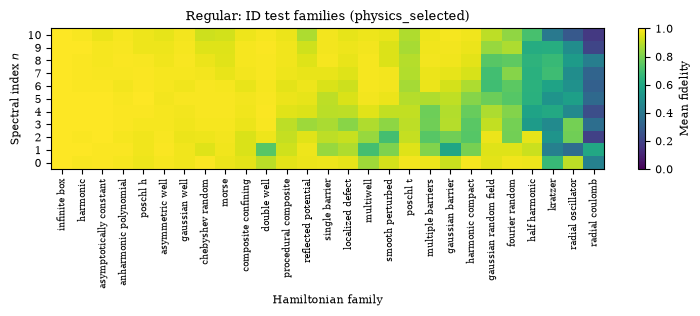

In [9]:
plt.rcParams.update({"font.family": "serif", "font.size": 8, "axes.linewidth": .8})
heatmap("ID_test", "Regular: ID test families", "regular_id")


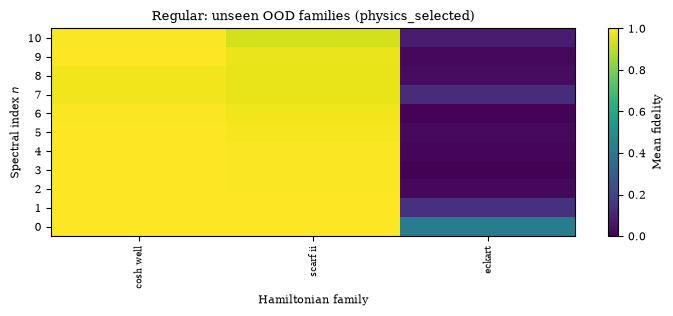

In [5]:
heatmap("unseen_analytical_functional_forms", "Regular: unseen OOD families", "regular_ood_unseen")


In [ ]:
assert {"ID_test", "unseen_analytical_functional_forms"} <= set(d.category)
print("HEATMAP AUDIT: PASS", {"mode": MODE, "route": ROUTE, "run": run.name})
